<a href="https://colab.research.google.com/github/BelenUrdangarin/Entregables---Urdangarin/blob/main/Notebook_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa Ingenias+ Data Science

En esta notebook, vamos a demostrar como funcionan los algoritmos vistos en clase y su implementación en Scikit-learn.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
data, target = load_iris(return_X_y=True, as_frame=True)

#return_X_y=True, Este parametro le dice a la función que devuelva los features y las etiquetas de forma separada en dos variables
#as_frame=True, Este parametro se asegura de que la data y la etiqueta se presenten como un dataframe de panda
#El dataset iris es muy utilizado para machine learning y contiene las medidas de 150 flores con
#50 muestras por cada tipo de flor

In [3]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
target.head()

,target
0,0
1,0
2,0
3,0
4,0


In [5]:
X = np.array(data) #convertimos la data en arrays
y = np.array(target)

In [6]:
feature_names = data.columns

# Random Forest

[Documentacion](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn-ensemble-randomforestclassifier)

In [7]:
from sklearn.ensemble import RandomForestClassifier
#Algoritmo de aprendizaje que utiliza arboles de decisión para hacer predicciones. estos dividen los datos
#en función de las caracteristicas relevantes para llegar a una predicción.

In [8]:
rf = RandomForestClassifier(n_estimators=200, criterion='entropy', max_features='sqrt')
#n_estimators, especifica el numero de arboles de decisión para contruir el forest. A mayor cantidad de estimadores, mejor es el resultado
#criterion='entropy', determina la función que mide la calidad de la separación en cada arbol de decisión
#Entropia se refiere a el criterio de ganancia de información. este criterio mide la impureza de las muestras
#max_features='sqrt', controla el numero de features a considerar cuando se busca la mejor separación
#en cada nodo del arbol de decisón, cuando se utiliza el ¨sqrt¨, el numero de features considerados
#en cada division será la raiz cuadrada del numero total de features en el dataset. esto ayuda a reducir
#la correlación de los arboles en el forest, lo que mejora la robustez del modelo


In [9]:
rf.fit(X, y) #Entrenamos el modelo

RandomForestClassifier(criterion='entropy', n_estimators=200)

In [10]:
estimator = rf.estimators_[5] #es una lista que contiene cada arbol de decisión individual
#Cada elemento en la lista es una instancia del arbol de decisión

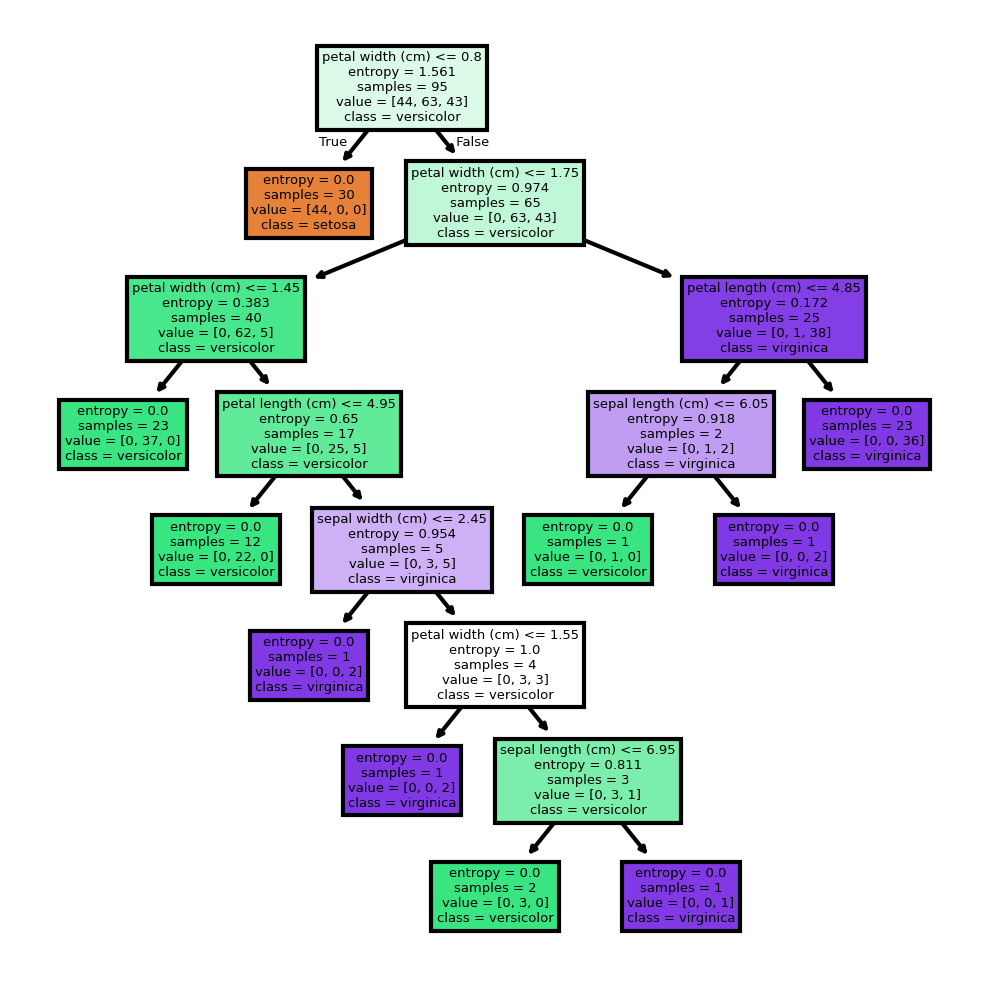

In [11]:
#Este codigo se utilizara para visualizar un arbol de decisión que conforma el random forest
from sklearn.tree import plot_tree

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi=300)
#El numero de filas y columnas indican que queremos un solo plot y dpi la cantidad de puntos por pulgada

plot_tree(rf[0], #selecciona el primer arbol de decision, rf.estimators contiene cada arbol individual
          feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'], #Provee la lista de nombres para los campos que seran mostrados en los nodos de decision para indicar que campo se usa para la division
          class_names=['setosa', 'versicolor', 'virginica'], #provee una lista de nombres que aparecen en las hojas del arbol que indica la marca predicha
          filled = True); #Colorea el nodo


En el contexto del arbol de decision, la entropia es el concepto prestado de la teoria de la informacion. Se utiliza para medir la impureza o desorden de la data. Cuando se arma un arbol de decision, la meta es hacer divisiones para reducir la impureza en los resultados, la entropia ayuda a cuantificar la impureza.
 - Si toda la data in la coleccion pertenece a la misma clase, el conjunto es considerado puro. No hay incertidumbre sobre la clase, la entropia se encuentra en su valor minimo (cero).
 - Si la data se encuentra mezclada y pertenece a diferentes clases, el set se considera impuro. Hay cierta incertidumbre sobre la clase de la data seleccionada de forma random para este set. cuantas mas mezclas de case se encuentren, mas alta es la impureza y su entropia. La entropia se encuentra en su maximo valor.

 Cuando se selecciona la division de nodos en base a la entropia, el algoritmo considera diferentes formas de dividir la data en base al campo y elige la division que resulta en la mayor disminucion de entropia. Una alta disminucion de entropia significa que la division se ha separado en grupos mas puros, haciendo que la claseficacion de data a futuro sea mas pura.


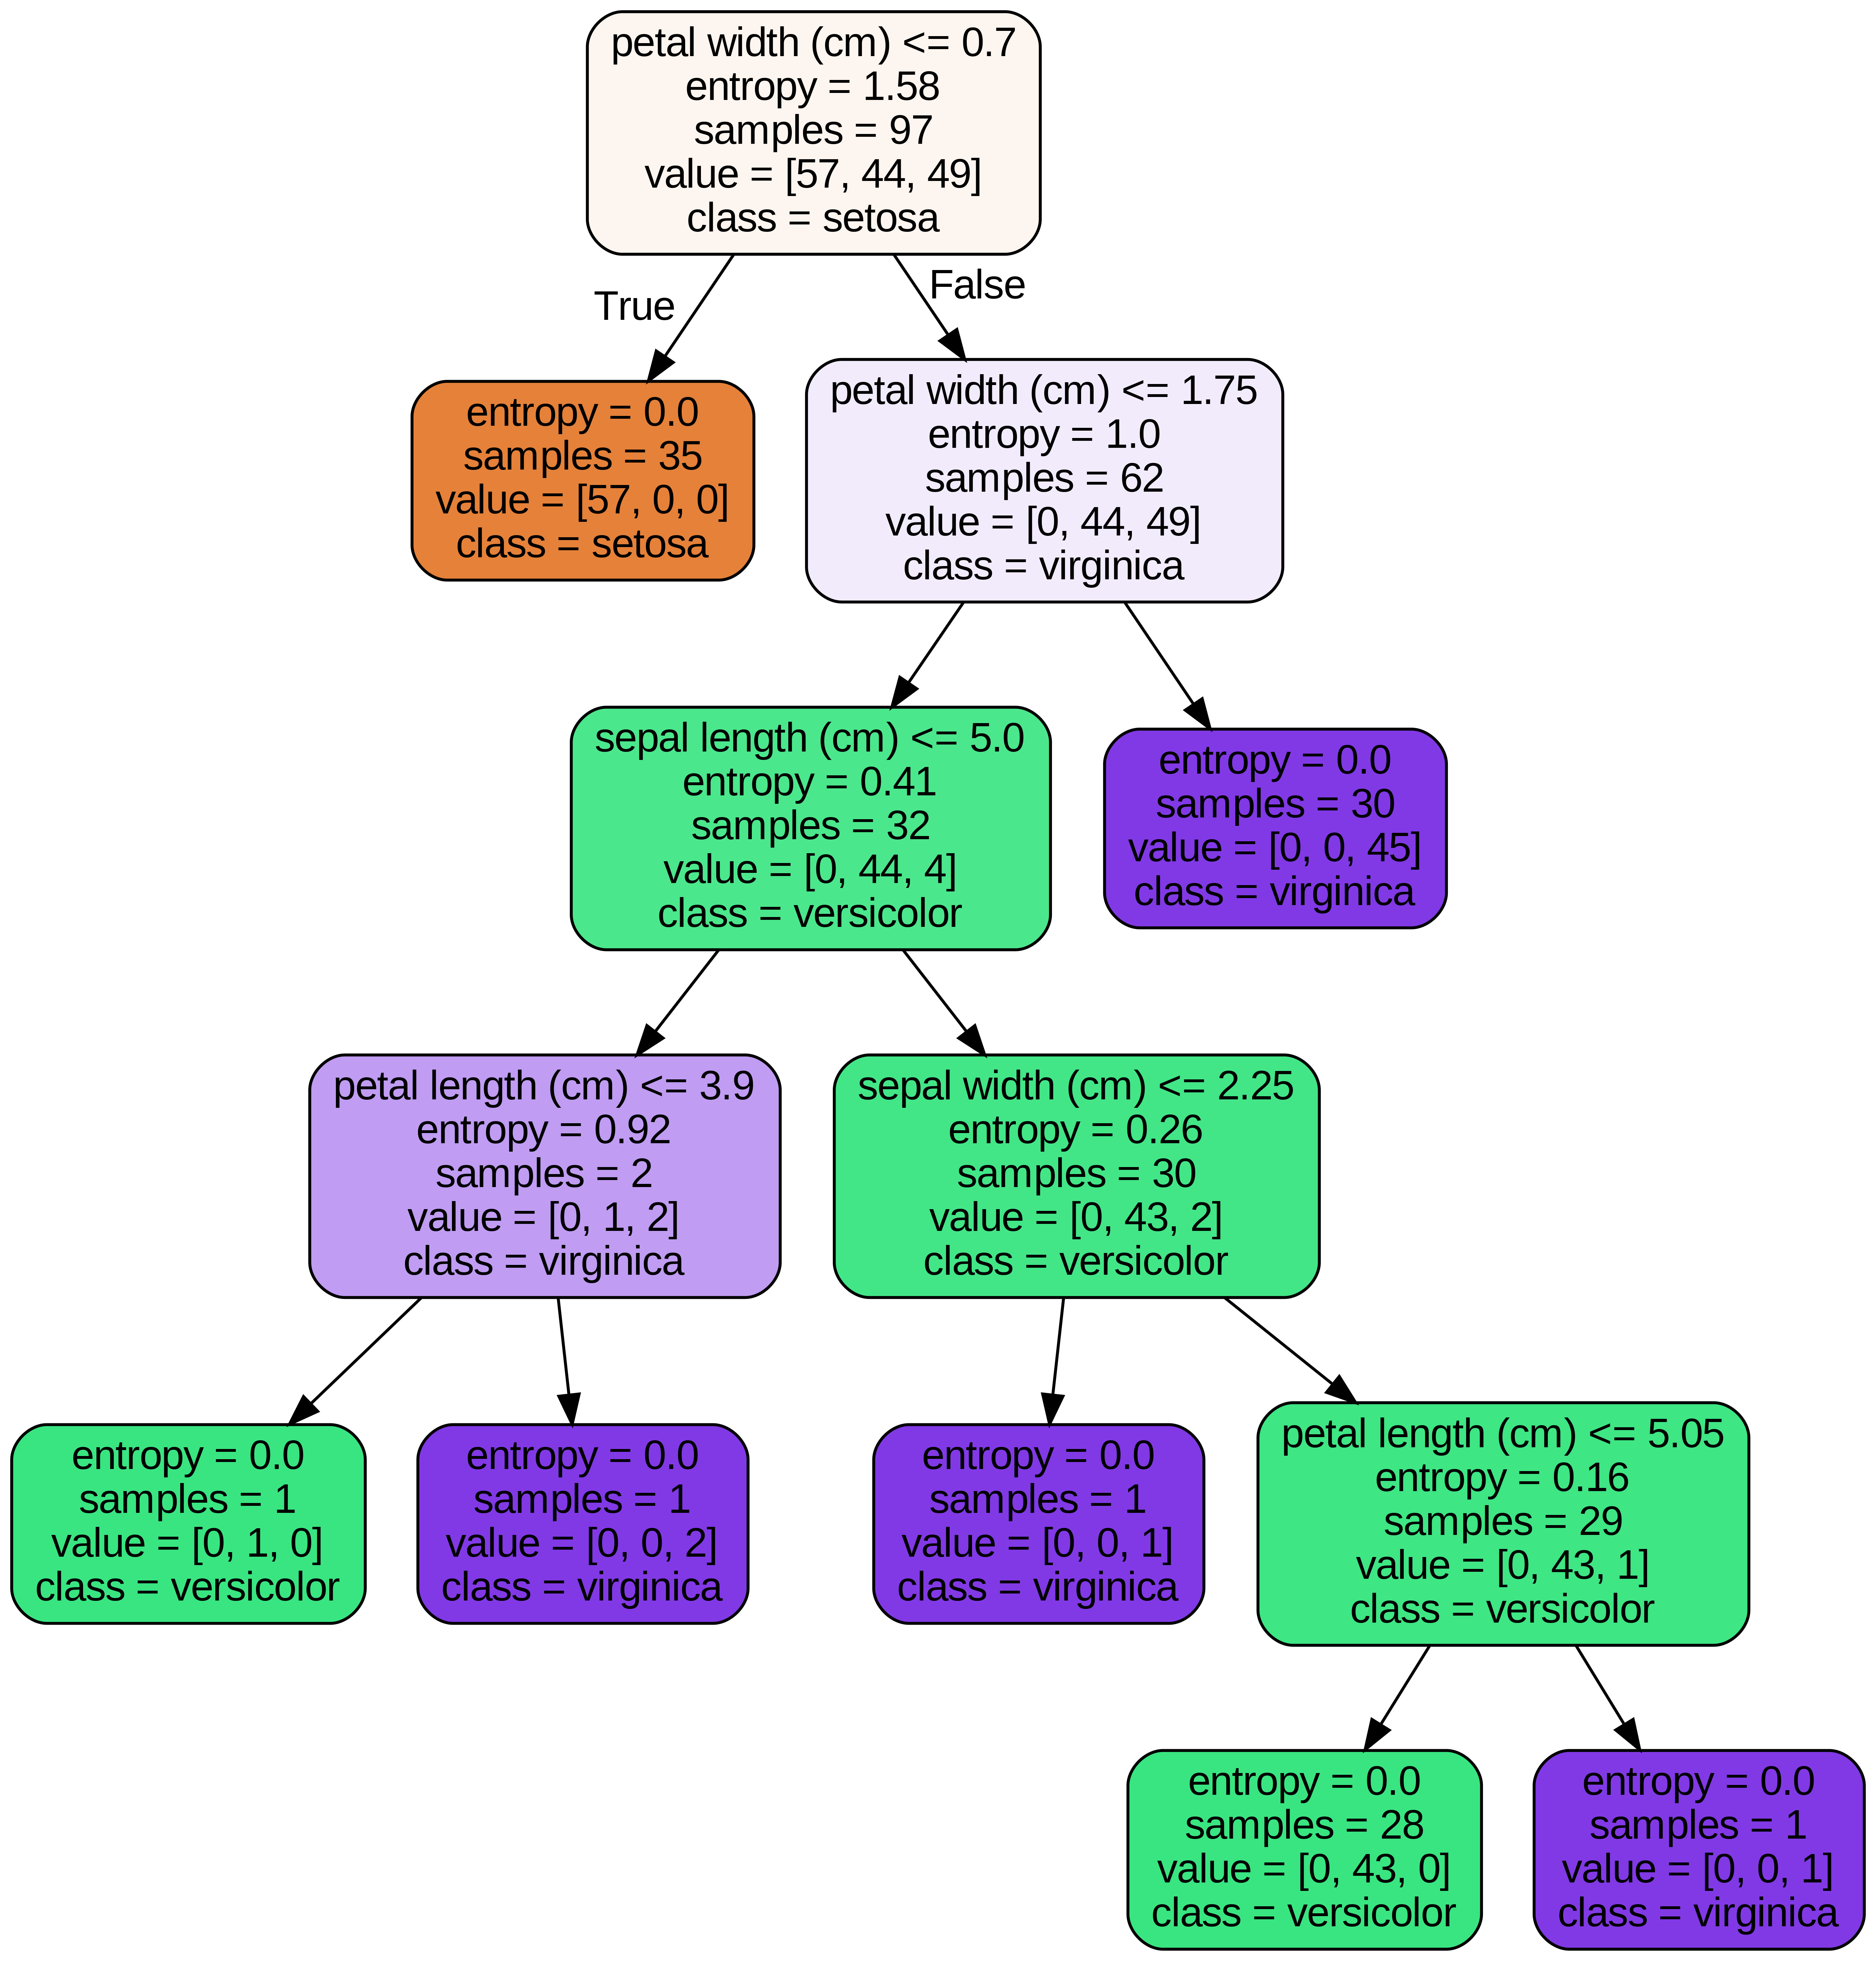

In [13]:
#Es otra forma de exportar un arbol de decision en el formato .dot que es un formato basado en texto para describir graficos
from sklearn.tree import export_graphviz

#la funcion importa un arbol de decision que se encuentra guardado en el estimator
#El estimator es un arbol de decision especifico dentro del clasificador.
export_graphviz(estimator, out_file='tree.dot', #Espicifica el nombre de archivo donde se guardará
                feature_names = iris.feature_names, #Provee el nombre de los features que se veran en los nodos del arbol
                class_names = iris.target_names,
                rounded = True, proportion = False,#Redondea los bordes de los nodos e indica que el tamaño de la caja en el nodo no sera proporcional a la cantidad de datos
                precision = 2, filled = True) #determina el numero de decimales y colorea los nodos

from subprocess import call
call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

from IPython.display import Image
Image(filename = 'tree.png')

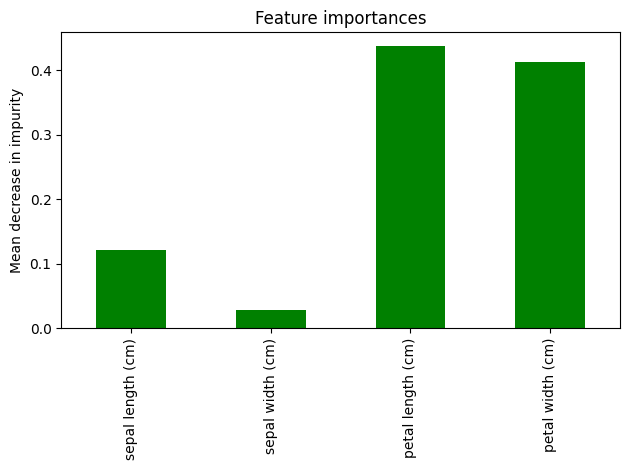

In [17]:
#Este grafico nos muestra la importancia de los diferentes features en el entrenamiento del random forest
#Lo que demuestra cual feature es el mas importante a la hora de tomar decisiones
#RF es el random forest entrenado, el feature importances contiene un array con un score por cada feature
#Un socre mas alto indica que el feature es mas importante para el la toma de decisiones en el modelo a traves del arbol de decision
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax, color='green')
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

#Esto demuestra que el atributo mas importante para realizar una division es el largo del petalo, seguido del ancho del petalo

# Support Vector Machine

In [18]:
from sklearn.svm import SVC, LinearSVC

#Esta seccion introduce el SVC un algoritmo utilizado para las tareas de clasificacion y regresion
#el SVC puede trabajar con informacion tanto lineal como no lineal usando diferentes funciones del kernel


In [22]:
X_ir = data.iloc[: ,[0, 2]]
#Selecciona columnas en especifico del dataframe y las asigna a otra variables, separa data para el odelo SVC

In [25]:
sup_vector = SVC()
#Inicializamos el SVC, el modelo esta listo para ser entrando con data

In [26]:
sup_vector.fit(X_ir, y)
#Entrenamos al modelo con la data que separamos

SVC()

In [28]:
sup_vector.support_vectors_
#El algoritmo trabaja al encontrar la mejor frontera para separar diferentes clases de data.
#La linea accede al atributo entrenado, el cual contiene un array de los vectores encontrados en el algoritmo SVM
#Los vectores son los puntos de data del modelo entrenado que son mas cercanos a la frontera de decision
#Estos son puntos de data criticos.

array([[4.3, 1.1],
       [5.7, 1.7],
       [5.1, 1.7],
       [4.8, 1.9],
       [5.1, 1.9],
       [7. , 4.7],
       [6.9, 4.9],
       [6.5, 4.6],
       [5.7, 4.5],
       [6.3, 4.7],
       [4.9, 3.3],
       [6.6, 4.6],
       [6.1, 4.7],
       [5.6, 4.5],
       [6.2, 4.5],
       [5.9, 4.8],
       [6.3, 4.9],
       [6.1, 4.7],
       [6.8, 4.8],
       [6.7, 5. ],
       [6. , 4.5],
       [6. , 5.1],
       [5.4, 4.5],
       [6. , 4.5],
       [6.7, 4.7],
       [5.5, 4.4],
       [6.1, 4.6],
       [5. , 3.3],
       [5.1, 3. ],
       [5.8, 5.1],
       [4.9, 4.5],
       [6.5, 5.1],
       [6.4, 5.3],
       [5.7, 5. ],
       [5.8, 5.1],
       [6.4, 5.3],
       [7.7, 6.9],
       [6. , 5. ],
       [5.6, 4.9],
       [6.3, 4.9],
       [6.2, 4.8],
       [6.1, 4.9],
       [7.9, 6.4],
       [6.3, 5.1],
       [6. , 4.8],
       [6.9, 5.4],
       [6.9, 5.1],
       [5.8, 5.1],
       [6.7, 5.2],
       [6.3, 5. ],
       [6.5, 5.2],
       [5.9, 5.1]])

In [29]:
sup_linear = LinearSVC()
#Llamamos al modelo lineal

In [30]:
sup_linear.fit(X_ir, y)
#Entrenamos el modelo lineal

LinearSVC()

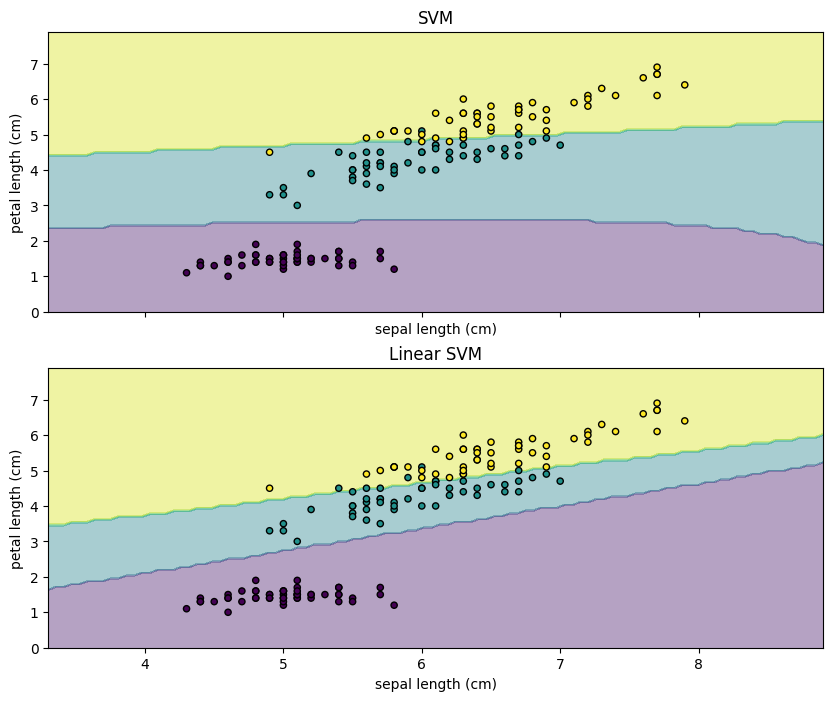

In [34]:
#Visualizamos las fronteras de decision que se crearon con los dos SVM, uno que usa una base radial
#y la otra que usa una base lineal
#Importamos librerias especificas para plottear las fronteras de decision
from sklearn.inspection import DecisionBoundaryDisplay
from itertools import product

f, ax = plt.subplots(2, 1, sharex="col", sharey="row", figsize=(10, 8))


DecisionBoundaryDisplay.from_estimator(
    sup_vector, X_ir, alpha=0.4, ax=ax[0], response_method="predict")
ax[0].scatter(X_ir.iloc[:, 0], X_ir.iloc[:, 1], c=y, s=20, edgecolor="k")
ax[0].set_title('SVM')

DecisionBoundaryDisplay.from_estimator(
    sup_linear, X_ir, alpha=0.4, ax=ax[1], response_method="predict")
ax[1].scatter(X_ir.iloc[:, 0], X_ir.iloc[:, 1], c=y, s=20, edgecolor="k")
ax[1].set_title('Linear SVM')

plt.show()

# kNN

In [39]:
from sklearn.neighbors import KNeighborsClassifier
#El algortimo del KNN es simple, es no parametrico y se usa para clasificacion  y regresion
#En clasificacion predice la clase de data point basada en la clase mas mayoritaria de los
#Vecinos "K" mas cercanos en la data entrenada. la K es un numero definido por el usuario

In [40]:
knn = KNeighborsClassifier(n_neighbors=3)
#el parametro pasado al contructor es el 3. establece el numero el numero de vecinos a considerar
#cuando se hacen predicciones a 3, el valor de defaul es el 5.
#Para determinar la clase de un nuevo punto, el algoritmo observara las clases de los 3 puntos de entrenamiento
#que estan mas cerca de el en el espacio de caracteristicas. la clase que sea mas frecuente entre
#esos 3 vecinos sera la clase asignada al nuevo punto
#Un valor de n mas pequeño da como resultado una frontera de decision menos suave o mas compleja
#por lo que el modelo sera mas sensible a las pequeñas variaciones en los datos locales. podria
#Capturar patrones mas intrincados, pero ser mas propenso a overfitting, si los datos no son
#perfectamente representativos


Un hiperparámetro es un parámetro que no se aprende directamente a partir de los datos durante el proceso de entrenamiento del modelo. En cambio, es un valor que se establece antes de que comience el entrenamiento. Estos parámetros controlan la estructura y el comportamiento del modelo de aprendizaje automático.

La elección de los hiperparámetros correctos puede tener un impacto significativo en el rendimiento del modelo.

 - Pre-entrenamiento: Se definen antes de iniciar el proceso de aprendizaje del modelo.
- No se aprenden de los datos: A diferencia de los parámetros del modelo (como los pesos en una red neuronal), que se ajustan iterativamente durante el entrenamiento basándose en los datos, los hiperparámetros son valores fijos durante una ejecución de entrenamiento específica.
- Influyen en el proceso de aprendizaje: Determinan cómo el algoritmo aprende, la complejidad del modelo, la velocidad de aprendizaje, etc.
- Requieren ajuste (tuning): Encontrar los valores óptimos para los hiperparámetros es a menudo un proceso iterativo que implica probar diferentes combinaciones y evaluar el rendimiento del modelo (generalmente en un conjunto de validación) para encontrar la mejor configuración. A esto se le llama ajuste de hiperparámetros o optimización de hiperparámetros.

Ejemplos de hiperparámetros en los algoritmos:

*Random Forest:*

- n_estimators: El número de árboles en el bosque.
- criterion: La función para medir la calidad de una división (por ejemplo, 'gini' o 'entropy').
- max_features: El número de características a considerar al buscar la mejor división.

*Support Vector Machines (SVM):*
- C: El parámetro de regularización.
- kernel: El tipo de función del núcleo ('linear', 'poly', 'rbf', etc.).
- gamma: Parámetro del núcleo para 'rbf', 'poly' y 'sigmoid'.

*k-Nearest Neighbors (kNN):*
- n_neighbors: El número de vecinos a considerar.

In [42]:
knn.fit(X_ir, y) #Entrenamos el modelo de KNN

KNeighborsClassifier(n_neighbors=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


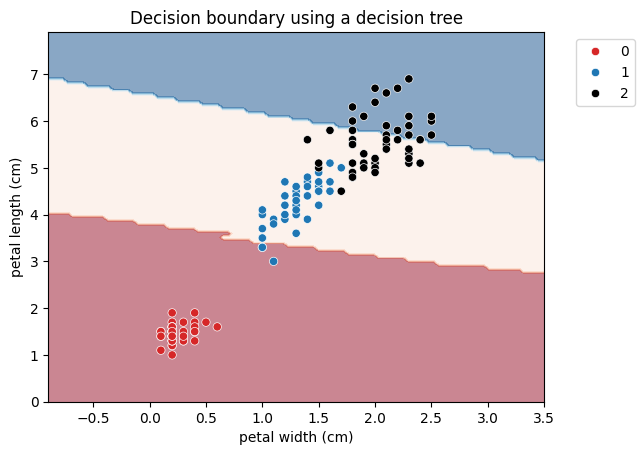

In [44]:
#El codigo se enfoca en visualizar la frontera de decision en el KNN
#La frontera de decision muestra las regiones en el espacio de features donde el modelo
#Clasificaria un nuevo data point en una clase especifica
palette = ["tab:red", "tab:blue", "black"]
columns = ['petal width (cm)', 'petal length (cm)']
data_all = data.copy()
data_all['target_column'] = y

DecisionBoundaryDisplay.from_estimator(
    knn, np.array(data[columns]), response_method="predict", cmap="RdBu", alpha=0.5
)
ax = sns.scatterplot(data=data_all, x=columns[0], y=columns[1],
                     hue='target_column', palette=palette)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
_ = plt.title("Decision boundary using a decision tree")